# 01 - Exploration des Données Financières

Ce notebook explore les datasets utilisés pour les expériences QMKL.

**Datasets disponibles :**
- German Credit (classification bon/mauvais risque crédit)
- Bank Marketing (prédiction souscription dépôt à terme)
- Custom (vos propres données financières)

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.loaders import load_dataset
from src.preprocessing import QuantumScaler, FeatureReducer

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Chargement des données

In [5]:
# Charger le dataset German Credit
# X, y = load_dataset('german_credit', n_samples=400, random_state=42)

from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=400, n_features=20, n_informative=12, 
    n_redundant=5, random_state=42, weights=[0.7, 0.3]
)
print(f'Data generated: X.shape={X.shape}')

print(f'Shape: {X.shape}')
print(f'Classes: {np.unique(y, return_counts=True)}')
print(f'Positive rate: {np.mean(y):.2%}')

Data generated: X.shape=(400, 20)
Shape: (400, 20)
Classes: (array([0, 1]), array([280, 120]))
Positive rate: 30.00%


## 2. Préprocessing pour l'encodage quantique

Variance expliquée cumulée (8 composantes): 91.39%


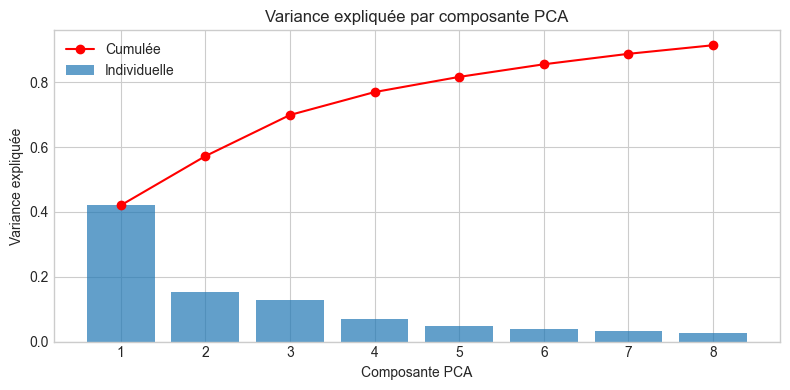

In [6]:
# Réduction de dimension via PCA
n_components = 8
reducer = FeatureReducer(n_components=n_components)
X_reduced = reducer.fit_transform(X)

# Variance expliquée
ev = reducer.get_explained_variance()
print(f'Variance expliquée cumulée ({n_components} composantes): {ev["total"]:.2%}')

plt.figure(figsize=(8, 4))
plt.bar(range(1, n_components+1), ev['per_component'], alpha=0.7, label='Individuelle')
plt.plot(range(1, n_components+1), ev['cumulative'], 'ro-', label='Cumulée')
plt.xlabel('Composante PCA')
plt.ylabel('Variance expliquée')
plt.title('Variance expliquée par composante PCA')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Scaling pour encodage quantique [0, 2]
scaler = QuantumScaler(feature_range=(0, 2))
X_scaled = scaler.fit_transform(X_reduced)

print(f'Range après scaling: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]')
print(f'Shape finale: {X_scaled.shape} -> {X_scaled.shape[1]} qubits nécessaires')

Range après scaling: [0.00, 2.00]
Shape finale: (400, 8) -> 8 qubits nécessaires


## 3. Distribution des features

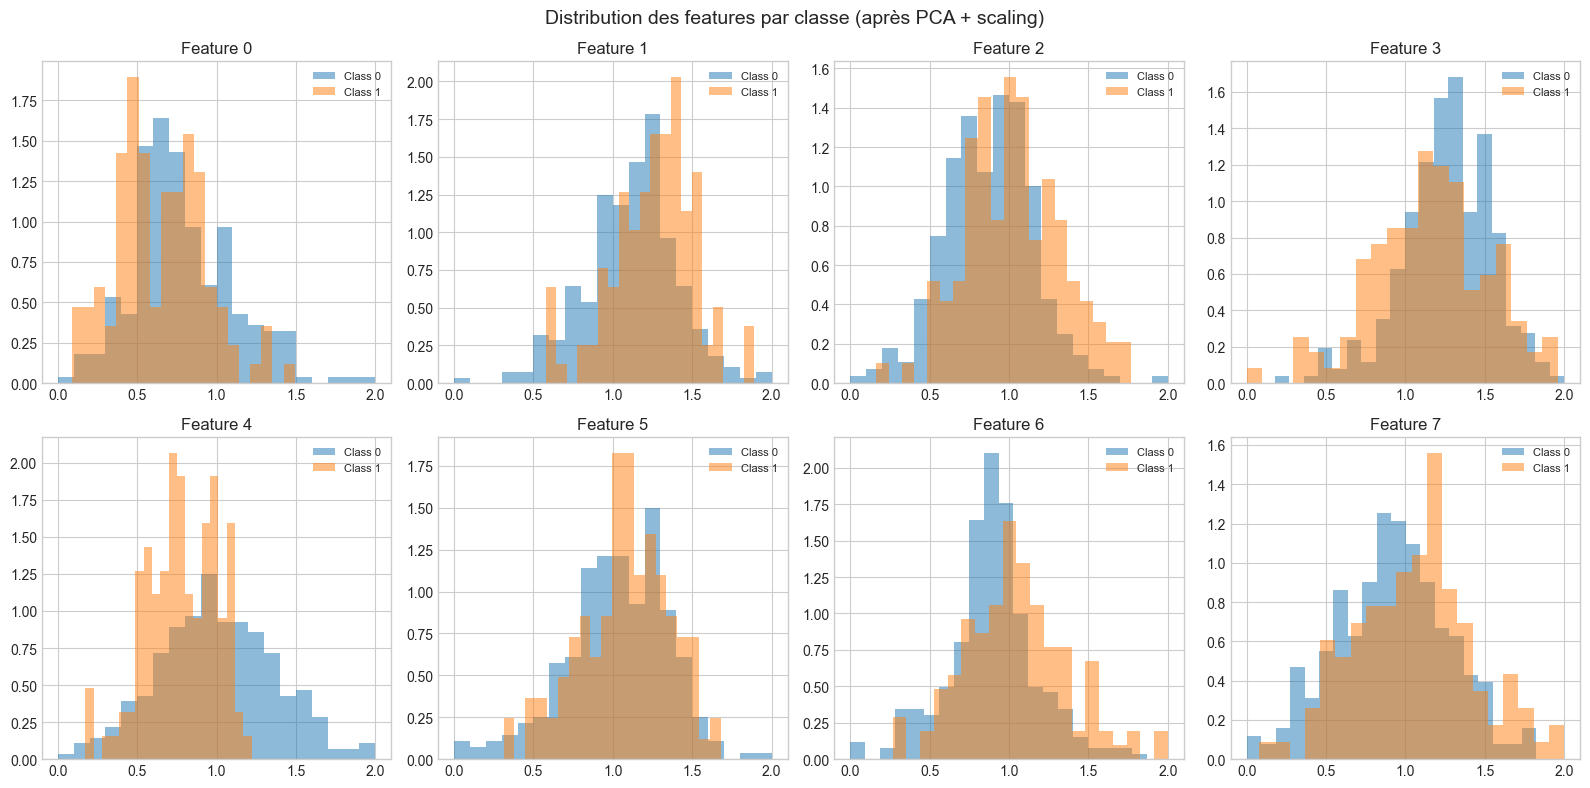

: 

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < X_scaled.shape[1]:
        ax.hist(X_scaled[y==0, i], bins=20, alpha=0.5, label='Class 0', density=True)
        ax.hist(X_scaled[y==1, i], bins=20, alpha=0.5, label='Class 1', density=True)
        ax.set_title(f'Feature {i}')
        ax.legend(fontsize=8)
plt.suptitle('Distribution des features par classe (après PCA + scaling)', fontsize=14)
plt.tight_layout()
plt.show()